# MDR-TS v20.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v20.3
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Combating variance and heteroscedasticity.

## 0. Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier

import torch

import statsmodels.api as sm
import statsmodels.stats.api as sms

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [ ]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


: 

In [ ]:
VERSION = "v20"
SUBVERSION = "v20.3"
RUN_NAME = "mdr_ts_v20_3"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v20/v20.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


: 

In [ ]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


: 

In [ ]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


: 

In [ ]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS_BASE = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "SMAP_sm_interp_lag1",
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollmean7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",

    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",

    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "G_DSLR",

    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
]

FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "SMAP_sm_interp_lag7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",

    "G_rain_sum_30d",

    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "slope", "elev",
]

def _check_cols(df, cols, name):
    missing = sorted(set(cols) - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

for _df_name, _df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    _check_cols(_df, KEEP_META_COLS + [TARGET_COL], _df_name)
    _check_cols(_df, FEATURE_COLS_BASE, f"{_df_name} (BASE)")
    _check_cols(_df, FEATURE_COLS_DRY, f"{_df_name} (DRY)")
    _check_cols(_df, FEATURE_COLS_WET, f"{_df_name} (WET)")

print("Columns locked")
print("  BASE features:", len(FEATURE_COLS_BASE))
print("  DRY  features:", len(FEATURE_COLS_DRY))
print("  WET  features:", len(FEATURE_COLS_WET))
print("  Target:", TARGET_COL)

Columns locked
  BASE features: 34
  DRY  features: 22
  WET  features: 28
  Target: soil_moisture_5cm


: 

In [ ]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

: 

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [ ]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


: 

In [ ]:
X_train_base = train_df[FEATURE_COLS_BASE].copy()
y_train = train_df[TARGET_COL].copy()

X_val_base = val_df[FEATURE_COLS_BASE].copy()
y_val = val_df[TARGET_COL].copy()

X_test_base = test_df[FEATURE_COLS_BASE].copy()
y_test = test_df[TARGET_COL].copy()

X_train_wet = train_df[FEATURE_COLS_WET].copy()
X_val_wet = val_df[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()

trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
X_trainval_base = trainval_df_d[FEATURE_COLS_BASE].copy()
y_trainval = trainval_df_d[TARGET_COL].copy()
X_trainval_wet = trainval_df_d[FEATURE_COLS_WET].copy()

print("\nMatrix shapes:")
print("  BASE train:", X_train_base.shape, "val:", X_val_base.shape, "test:", X_test_base.shape)
print("  WET  train:", X_train_wet.shape,  "val:", X_val_wet.shape,  "test:", X_test_wet.shape)
print("  BASE trainval:", X_trainval_base.shape, "WET trainval:", X_trainval_wet.shape)


Matrix shapes:
  BASE train: (6868, 34) val: (2720, 34) test: (4016, 34)
  WET  train: (6868, 28) val: (2720, 28) test: (4016, 28)
  BASE trainval: (9588, 34) WET trainval: (9588, 28)


: 

### Inner Split

In [ ]:
t1 = 0.20
t2 = 0.313

y_train_arr = np.asarray(y_train).ravel()
reg_train = np.zeros_like(y_train_arr, dtype=int)
reg_train[(y_train_arr > t1) & (y_train_arr <= t2)] = 1
reg_train[y_train_arr > t2] = 2

y_val_arr = np.asarray(y_val).ravel()
reg_val = np.zeros_like(y_val_arr, dtype=int)
reg_val[(y_val_arr > t1) & (y_val_arr <= t2)] = 1
reg_val[y_val_arr > t2] = 2

print("Train regime counts:",
      {r: int((reg_train == r).sum()) for r in [0,1,2]})
print("Val regime counts:",
      {r: int((reg_val == r).sum()) for r in [0,1,2]})

Train regime counts: {0: 3292, 1: 2729, 2: 847}
Val regime counts: {0: 988, 1: 1156, 2: 576}


: 

### Base Model

In [ ]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=8000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
)

XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.9,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=0.3,
    reg_alpha=0.0,
)

: 

In [ ]:
xgb_dry = XGBRegressor(**XGB_PARAMS_DRY)
xgb_transition = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_wet = XGBRegressor(**XGB_PARAMS_WET)

: 

In [ ]:
w_dry = np.ones_like(reg_train, dtype=float)
w_dry[reg_train == 0] = 1.0     # dry
w_dry[reg_train == 1] = 0.10    # transition
w_dry[reg_train == 2] = 0.01    # wet

xgb_dry.fit(
    X_train_base,
    y_train,
    sample_weight=w_dry,
    verbose=0
)

pred_dry_train = xgb_dry.predict(X_train_base)
pred_dry_val = xgb_dry.predict(X_val_base)
pred_dry_test = xgb_dry.predict(X_test_base)

: 

In [ ]:
X_train_aug = np.column_stack([X_train_wet.values, np.asarray(pred_dry_train).ravel()])
X_val_aug   = np.column_stack([X_val_wet.values,   np.asarray(pred_dry_val).ravel()])
X_test_aug  = np.column_stack([X_test_wet.values,  np.asarray(pred_dry_test).ravel()])

w_trn = np.ones_like(reg_train, dtype=float)
w_trn[reg_train == 0] = 0.10    # dry
w_trn[reg_train == 1] = 1.0     # transition
w_trn[reg_train == 2] = 0.10    # wet

xgb_transition.fit(
    X_train_aug,
    y_train,
    sample_weight=w_trn,
    verbose=0
)

pred_transition_train = xgb_transition.predict(X_train_aug)
pred_transition_val   = xgb_transition.predict(X_val_aug)
pred_transition_test  = xgb_transition.predict(X_test_aug)

: 

In [ ]:
w_wet = np.ones_like(reg_train, dtype=float)
w_wet[reg_train == 0] = 0.01    # dry
w_wet[reg_train == 1] = 0.10    # transition
w_wet[reg_train == 2] = 1.0     # wet

xgb_wet.fit(
    X_train_aug,
    y_train,
    sample_weight=w_wet,
    verbose=0
)

pred_wet_train = xgb_wet.predict(X_train_aug)
pred_wet_val   = xgb_wet.predict(X_val_aug)
pred_wet_test  = xgb_wet.predict(X_test_aug)

: 

In [ ]:
print("Weight means:", w_dry.mean(), w_trn.mean(), w_wet.mean())

Weight means: 0.520292661619103 0.4576150262085032 0.16785381479324404


: 

In [ ]:
y_test_arr = np.asarray(y_test).ravel()

reg_test = np.zeros_like(y_test_arr, dtype=int)
reg_test[(y_test_arr > t1) & (y_test_arr <= t2)] = 1
reg_test[y_test_arr > t2] = 2

mask_dry_test = reg_test == 0
mask_transition_test = reg_test == 1
mask_wet_test = reg_test == 2

print("Test regime counts:")
print("  dry:", mask_dry_test.sum())
print("  transition:", mask_transition_test.sum())
print("  wet:", mask_wet_test.sum())

Test regime counts:
  dry: 1509
  transition: 2015
  wet: 492


: 

In [ ]:
metrics_dashboard(y_val, pred_dry_val, name="DRY Expert (weighted) | VAL", return_dict=False)

: 

In [ ]:
neat_print(get_metrics_dict(y_val, pred_dry_val, prefix=""), "DRY REGIME")


DRY REGIME
Metric                          Value
------------------------------------------
n                               2,720
r2                            0.84882
mae                           0.03238
rmse                          0.04085
ubrmse                        0.03854
bias                          0.01354
med_ae                        0.02799
p90_ae                        0.06698
q05_err                      -0.04553
q50_err                       0.01284
q95_err                       0.07642


: 

In [ ]:
metrics_dashboard(y_val, pred_transition_val, name="TRANSITION Expert (weighted) | VAL", return_dict=False)

: 

In [ ]:
neat_print(get_metrics_dict(y_val, pred_transition_val, prefix=""), "TRANSITION REGIME")


TRANSITION REGIME
Metric                          Value
------------------------------------------
n                               2,720
r2                            0.84233
mae                           0.03186
rmse                          0.04172
ubrmse                        0.04119
bias                          0.00666
med_ae                        0.02600
p90_ae                        0.06427
q05_err                      -0.06281
q50_err                       0.00981
q95_err                       0.06499


: 

In [ ]:
metrics_dashboard(y_val, pred_wet_val, name="WET Expert (weighted) | VAL", return_dict=False)

: 

In [ ]:
neat_print(get_metrics_dict(y_val, pred_wet_val, prefix=""), "WET REGIME")


WET REGIME
Metric                          Value
------------------------------------------
n                               2,720
r2                            0.85459
mae                           0.02999
rmse                          0.04007
ubrmse                        0.03988
bias                          0.00388
med_ae                        0.02383
p90_ae                        0.06168
q05_err                      -0.05895
q50_err                       0.00485
q95_err                       0.06397


: 

In [ ]:
neat_print(get_metrics_dict(y_val, pred_dry_val, prefix=""), "DRY REGIME | VAL")
neat_print(get_metrics_dict(y_val, pred_transition_val, prefix=""), "TRANSITION REGIME | VAL")
neat_print(get_metrics_dict(y_val, pred_wet_val, prefix=""), "WET REGIME | VAL")


DRY REGIME | VAL
Metric                          Value
------------------------------------------
n                               2,720
r2                            0.84882
mae                           0.03238
rmse                          0.04085
ubrmse                        0.03854
bias                          0.01354
med_ae                        0.02799
p90_ae                        0.06698
q05_err                      -0.04553
q50_err                       0.01284
q95_err                       0.07642

TRANSITION REGIME | VAL
Metric                          Value
------------------------------------------
n                               2,720
r2                            0.84233
mae                           0.03186
rmse                          0.04172
ubrmse                        0.04119
bias                          0.00666
med_ae                        0.02600
p90_ae                        0.06427
q05_err                      -0.06281
q50_err                       0.009

: 

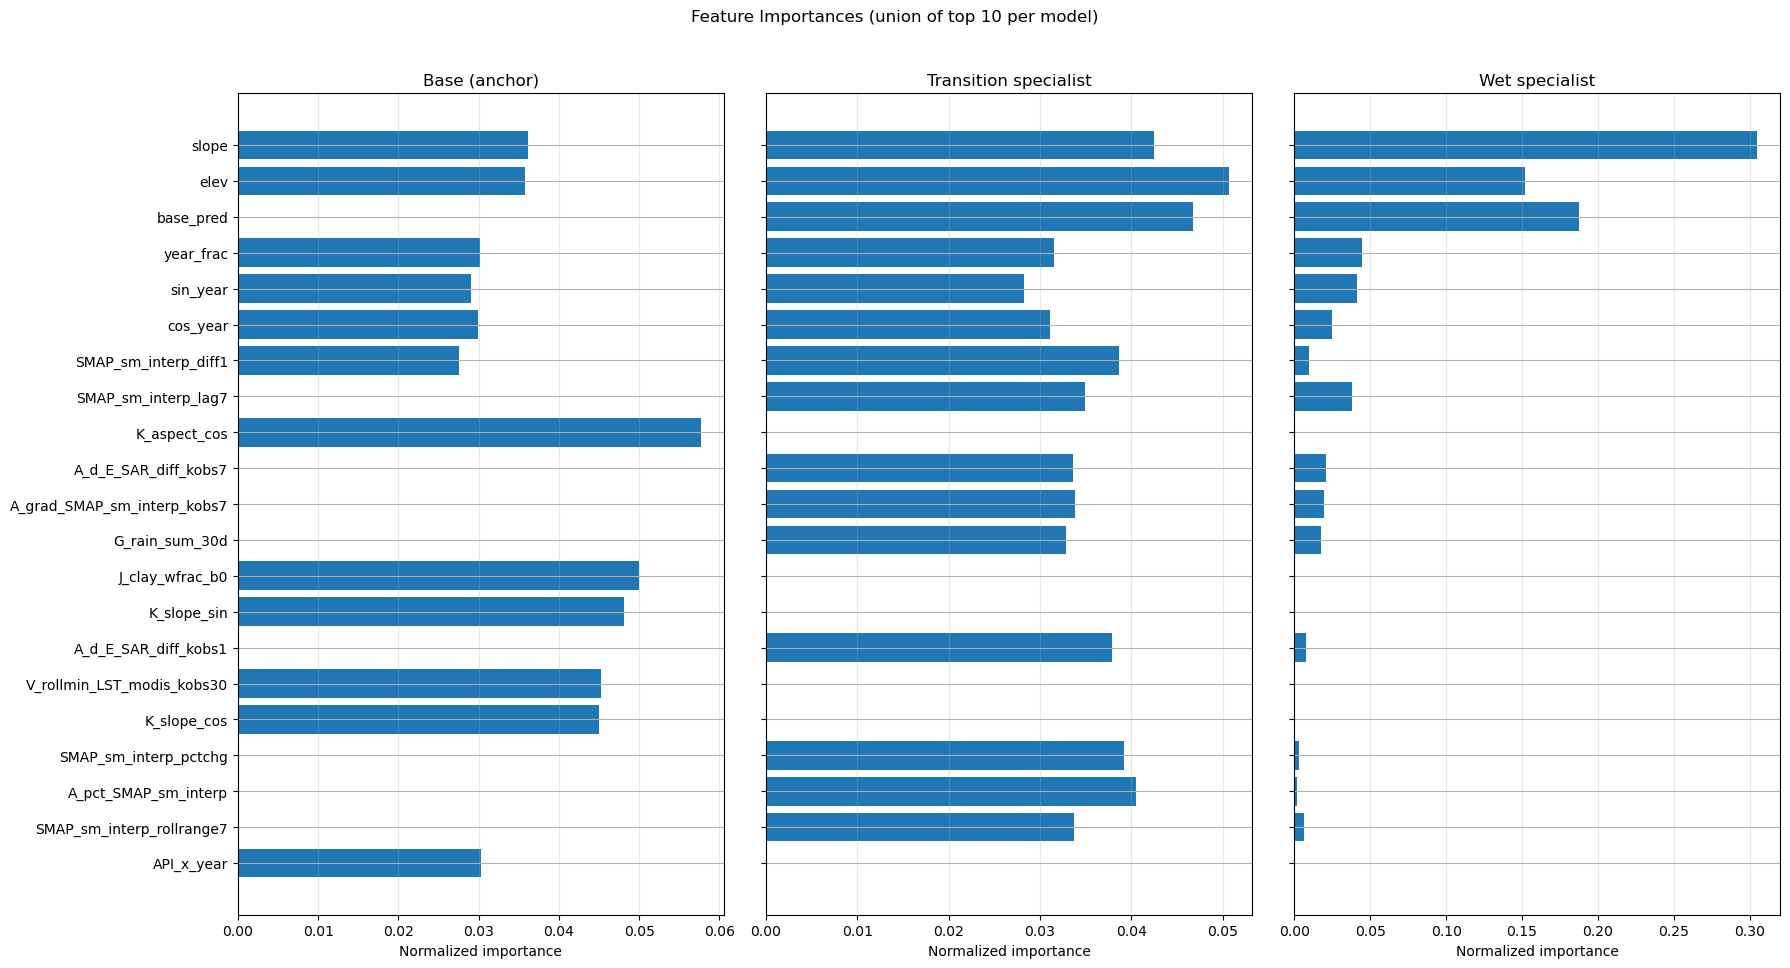

: 

In [ ]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 10

cols_base = list(FEATURE_COLS_BASE)
cols_aug = list(FEATURE_COLS_WET) + ["base_pred"]

imp_base = get_xgb_importance(xgb_dry, cols_base)
imp_trn  = get_xgb_importance(xgb_transition, cols_aug)
imp_wet  = get_xgb_importance(xgb_wet, cols_aug)

top_feats = sorted(set(
    imp_base.sort_values(ascending=False).head(TOP_K).index
) | set(
    imp_trn.sort_values(ascending=False).head(TOP_K).index
) | set(
    imp_wet.sort_values(ascending=False).head(TOP_K).index
))

cmp = pd.DataFrame({
    "base": imp_base.reindex(top_feats, fill_value=0.0),
    "transition": imp_trn.reindex(top_feats, fill_value=0.0),
    "wet": imp_wet.reindex(top_feats, fill_value=0.0),
})

cmp["mean"] = cmp[["base", "transition", "wet"]].mean(axis=1)
cmp = cmp.sort_values("mean", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, max(6, 0.45 * len(cmp))), sharey=True)

y = np.arange(len(cmp))

axes[0].barh(y, cmp["base"].values)
axes[0].set_title("Base (anchor)")
axes[0].set_xlabel("Normalized importance")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(y, cmp["transition"].values)
axes[1].set_title("Transition specialist")
axes[1].set_xlabel("Normalized importance")
axes[1].grid(axis="x", alpha=0.3)

axes[2].barh(y, cmp["wet"].values)
axes[2].set_title("Wet specialist")
axes[2].set_xlabel("Normalized importance")
axes[2].grid(axis="x", alpha=0.3)

axes[0].set_yticks(y)
axes[0].set_yticklabels(cmp.index)

plt.suptitle(f"Feature Importances (union of top {TOP_K} per model)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
metrics_dashboard(y_test, pred_wet_test, name="WET Expert (weighted) | TEST", return_dict=False)
metrics_dashboard(y_test, pred_transition_test, name="TRANSITION Expert (weighted) | TEST", return_dict=False)
metrics_dashboard(y_test, pred_dry_test, name="DRY Expert (weighted) | TEST", return_dict=False)

: 

In [ ]:
neat_print(get_metrics_dict(y_test, pred_dry_test, prefix=""), "DRY REGIME | TEST")
neat_print(get_metrics_dict(y_test, pred_transition_test, prefix=""), "TRANSITION REGIME | TEST")
neat_print(get_metrics_dict(y_test, pred_wet_test, prefix=""), "WET REGIME | TEST")


DRY REGIME | TEST
Metric                          Value
------------------------------------------
n                               4,016
r2                            0.78007
mae                           0.03497
rmse                          0.04416
ubrmse                        0.04397
bias                          0.00404
med_ae                        0.02855
p90_ae                        0.07037
q05_err                      -0.07014
q50_err                       0.00507
q95_err                       0.07076

TRANSITION REGIME | TEST
Metric                          Value
------------------------------------------
n                               4,016
r2                            0.76079
mae                           0.03484
rmse                          0.04605
ubrmse                        0.04579
bias                         -0.00497
med_ae                        0.02638
p90_ae                        0.07545
q05_err                      -0.08966
q50_err                      -0.0

: 

### Residuals

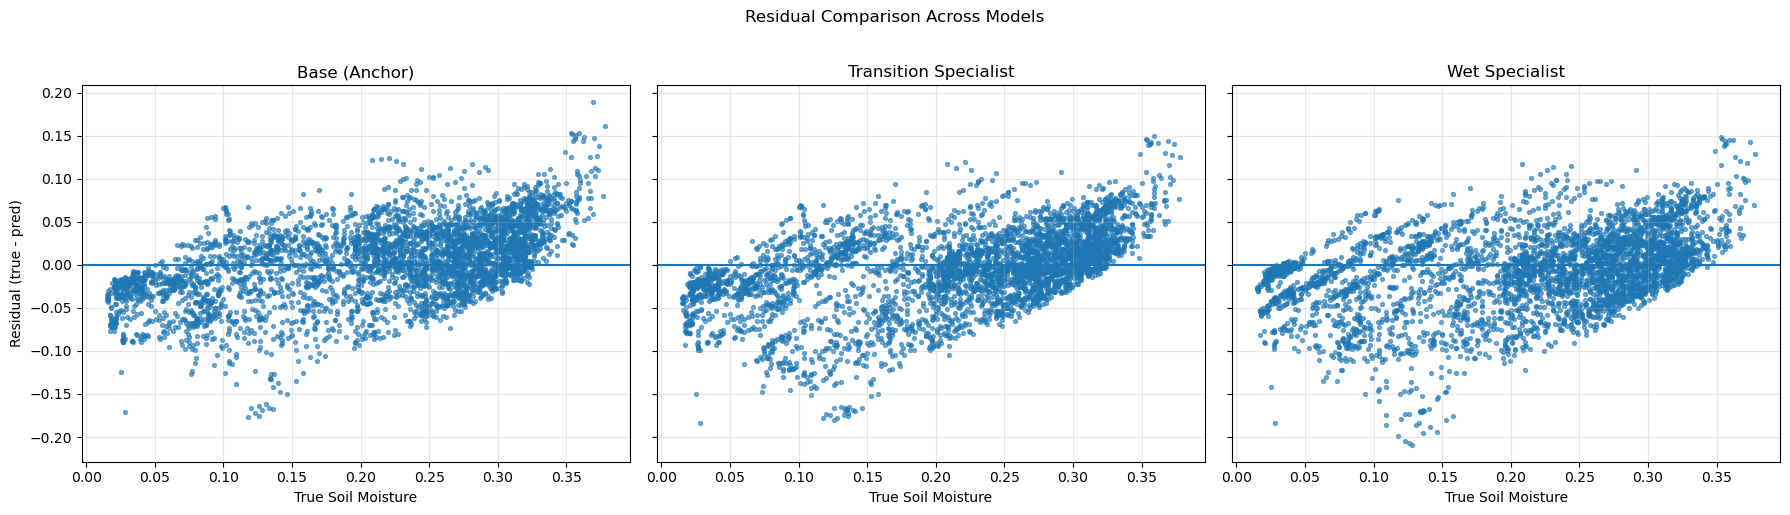

: 

In [ ]:
y_true = np.asarray(y_test).ravel()

pred_base = np.asarray(pred_dry_test).ravel()
pred_trn  = np.asarray(pred_transition_test).ravel()
pred_wet  = np.asarray(pred_wet_test).ravel()

res_base = y_true - pred_base
res_trn  = y_true - pred_trn
res_wet  = y_true - pred_wet

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(y_true, res_base, s=8, alpha=0.6)
axes[0].axhline(0)
axes[0].set_title("Base (Anchor)")
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_true, res_trn, s=8, alpha=0.6)
axes[1].axhline(0)
axes[1].set_title("Transition Specialist")
axes[1].set_xlabel("True Soil Moisture")
axes[1].grid(alpha=0.3)

axes[2].scatter(y_true, res_wet, s=8, alpha=0.6)
axes[2].axhline(0)
axes[2].set_title("Wet Specialist")
axes[2].set_xlabel("True Soil Moisture")
axes[2].grid(alpha=0.3)

plt.suptitle("Residual Comparison Across Models", y=1.02)
plt.tight_layout()
plt.show()

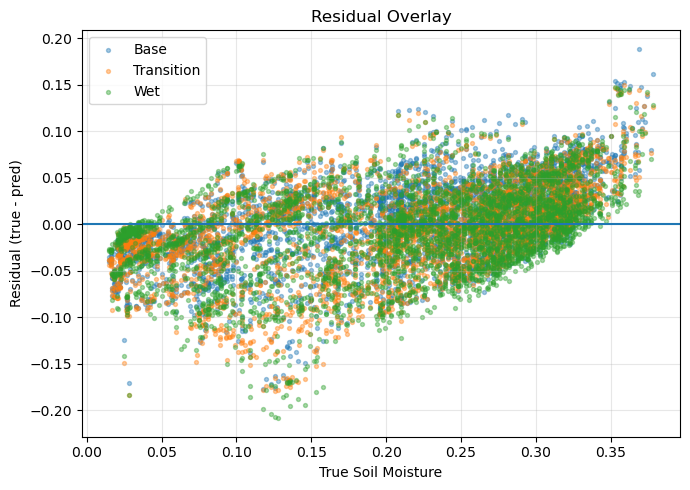

: 

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(y_true, res_base, s=8, alpha=0.4, label="Base")
plt.scatter(y_true, res_trn,  s=8, alpha=0.4, label="Transition")
plt.scatter(y_true, res_wet,  s=8, alpha=0.4, label="Wet")

plt.axhline(0)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residual Overlay")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Classifier

In [ ]:
def add_dynamic_label(df, target_col, station_col="station_id", date_col="date", eps=0.005):

    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values([station_col, date_col]).reset_index(drop=True)

    d["y_lag1"] = d.groupby(station_col)[target_col].shift(1)
    d["dy"] = d[target_col] - d["y_lag1"]

    d = d.dropna(subset=["y_lag1"]).reset_index(drop=True)

    dyn = np.ones(len(d), dtype=int)
    dyn[d["dy"].values < -eps] = 0
    dyn[d["dy"].values >  eps] = 2
    d["dyn_lbl"] = dyn

    return d

eps = 0.005
train_dyn = add_dynamic_label(train_df, TARGET_COL, eps=eps)
val_dyn   = add_dynamic_label(val_df,   TARGET_COL, eps=eps)

print("Dynamic label counts (train):", train_dyn["dyn_lbl"].value_counts().to_dict())
print("Dynamic label counts (val):  ", val_dyn["dyn_lbl"].value_counts().to_dict())

Dynamic label counts (train): {1: 3361, 0: 2242, 2: 1260}
Dynamic label counts (val):   {1: 1358, 0: 824, 2: 534}


: 

In [ ]:
CLF_COLS = sorted(set(FEATURE_COLS_BASE) | set(FEATURE_COLS_WET))
REG_COLS = FEATURE_COLS_BASE

X_clf_tr = train_dyn[CLF_COLS].copy()
y_clf_tr = train_dyn["dyn_lbl"].values

X_clf_va = val_dyn[CLF_COLS].copy()
y_clf_va = val_dyn["dyn_lbl"].values

X_reg_tr = train_dyn[REG_COLS].copy()
y_reg_tr = train_dyn[TARGET_COL].values

X_reg_va = val_dyn[REG_COLS].copy()
y_reg_va = val_dyn[TARGET_COL].values

# Test is only for inference/eval; no labels needed
X_clf_te = test_df[CLF_COLS].copy()
X_reg_te = test_df[REG_COLS].copy()

print("CLF dims:", X_clf_tr.shape, X_clf_va.shape, X_clf_te.shape)
print("REG dims:", X_reg_tr.shape, X_reg_va.shape, X_reg_te.shape)

CLF dims: (6863, 50) (2716, 50) (4016, 50)
REG dims: (6863, 34) (2716, 34) (4016, 34)


: 

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_clf_tr_i = imputer.fit_transform(X_clf_tr)
X_clf_va_i = imputer.transform(X_clf_va)
X_clf_te_i = imputer.transform(X_clf_te)

: 

Classifier val accuracy: 0.6170839469808542
              precision    recall  f1-score   support

   drying(0)       0.55      0.49      0.52       824
   stable(1)       0.75      0.74      0.74      1358
  wetting(2)       0.43      0.51      0.47       534

    accuracy                           0.62      2716
   macro avg       0.57      0.58      0.57      2716
weighted avg       0.62      0.62      0.62      2716



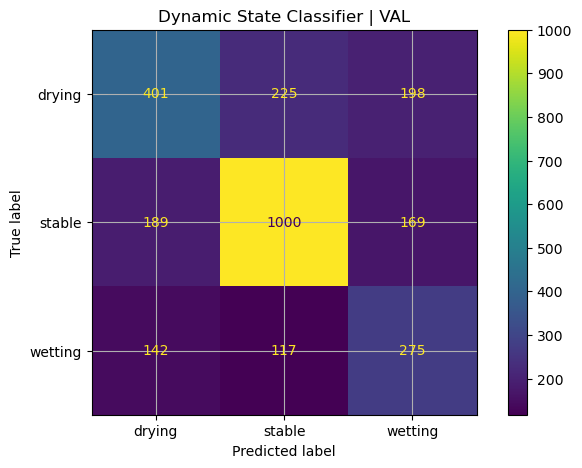

: 

In [ ]:
from sklearn.metrics import accuracy_score

counts = np.bincount(y_clf_tr, minlength=3).astype(float)
class_w = counts.sum() / (3.0 * counts)
sample_w = class_w[y_clf_tr]

CLF_PARAMS = dict(
    objective="multi:softprob",
    num_class=3,
    random_state=SEED,
    n_jobs=-1,
    max_depth=6,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    n_estimators=1500,
    learning_rate=0.03,
    reg_lambda=2.0,
)

clf = XGBClassifier(**CLF_PARAMS)
clf.fit(X_clf_tr_i, y_clf_tr, sample_weight=sample_w, verbose=0)

proba_va = clf.predict_proba(X_clf_va_i)
pred_va_lbl = np.argmax(proba_va, axis=1)

print("Classifier val accuracy:", accuracy_score(y_clf_va, pred_va_lbl))
print(classification_report(y_clf_va, pred_va_lbl, target_names=["drying(0)","stable(1)","wetting(2)"]))

cm = confusion_matrix(y_clf_va, pred_va_lbl, labels=[0,1,2])
disp = ConfusionMatrixDisplay(cm, display_labels=["drying","stable","wetting"])
disp.plot(values_format="d")
plt.title("Dynamic State Classifier | VAL")
plt.show()

In [ ]:
REG_PARAMS = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=8,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=1.5,
    reg_alpha=0.03,
)

reg0 = XGBRegressor(**REG_PARAMS)  # drying
reg1 = XGBRegressor(**REG_PARAMS)  # stable
reg2 = XGBRegressor(**REG_PARAMS)  # wetting

m0 = (train_dyn["dyn_lbl"].values == 0)
m1 = (train_dyn["dyn_lbl"].values == 1)
m2 = (train_dyn["dyn_lbl"].values == 2)

reg0.fit(X_reg_tr[m0], y_reg_tr[m0], verbose=0)
reg1.fit(X_reg_tr[m1], y_reg_tr[m1], verbose=0)
reg2.fit(X_reg_tr[m2], y_reg_tr[m2], verbose=0)

# Predict everywhere (val/test)
p0_va = reg0.predict(X_reg_va)
p1_va = reg1.predict(X_reg_va)
p2_va = reg2.predict(X_reg_va)

p0_te = reg0.predict(X_reg_te)
p1_te = reg1.predict(X_reg_te)
p2_te = reg2.predict(X_reg_te)

: 

In [ ]:
# Probabilities on test
proba_te = clf.predict_proba(X_clf_te_i)

pred_val = proba_va[:,0]*p0_va + proba_va[:,1]*p1_va + proba_va[:,2]*p2_va
pred_test = proba_te[:,0]*p0_te + proba_te[:,1]*p1_te + proba_te[:,2]*p2_te

metrics_dashboard(y_reg_va, pred_val, name=f"FINAL | Dynamic-MoE (eps={eps}) | VAL", return_dict=False)
metrics_dashboard(y_test,   pred_test, name=f"FINAL | Dynamic-MoE (eps={eps}) | TEST", return_dict=False)

: 

---

_Jakob Balkovec_